In [19]:
#import requests
import json 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
#from Bio import Entrez
#import sys
import math
#from collections import namedtuple

In [20]:
with open("gene_set_results/pk_dict.json") as pk:
    pk_dict = json.load(pk)
with open("gene_set_results/pd_dict.json") as p:
    pd_dict = json.load(p)
with open("gene_set_results/sonis_dict.json") as s:
    sonis_dict = json.load(s)
with open("gene_set_results/string_candidate_gene_dict.json") as st:
    string_dict = json.load(st)
#Enrichr reconciliation of the other gene sets other than sonis gene_set
combined_dict = {**pk_dict, **pd_dict, **string_dict, **sonis_dict}

### Enrichr reconcilliation for gene sets other than Sonis set

Define function to call Enrichr API for gene set enrichment 

In [3]:
import gseapy as gp
def get_enrichr_txt(input_list, library):
    enr = gp.enrichr(gene_list=input_list,
                    gene_sets= library,
                    organism='Human', # don't forget to set organism to the one you desired! e.g. Yeast
#                     description="sonis_pathways",
                    no_plot=True,
                    cutoff = 0.05 #  Show enriched terms which Adjusted P-value < cutoff.
                    )
    df = enr.results
    return df



In [4]:
# Only select the best matched theme from Enrichr for each gene set
def enrichr(dict): 
    df_list = []
    for sublist in dict.values():    
        df_enr = get_enrichr_txt(sublist, library).sort_values(["Combined Score"], ascending=False).iloc[0:1]
        new_df = df_enr.drop(["Adjusted P-value", "Old P-value", "Old Adjusted P-value", "Odds Ratio", "P-value","Combined Score"], axis=1 )
        df_list.append(new_df)

    summary_df = pd.concat(df_list)
    return summary_df

Enrichr Top Themes from MSigDB Hallmark Database

In [5]:
library = ["MSigDB_Hallmark_2020"]

In [7]:
combined  = enrichr(combined_dict)

In [8]:
#Subset the relevant information into a dataframe and sort alphabetically by Term 
combined = combined[["Gene_set","Term","Overlap"]].sort_values(by = "Term")

In [9]:
combined["gene_set_name"] = combined_dict.keys() 

In [10]:
combined.rename(columns = {'Gene_set':'library'}, inplace=True)
size = [len(sub) for sub in combined_dict.values()]
combined["original_size"] = size


In [11]:
combined

,library,Term,Overlap,gene_set_name,original_size
0,MSigDB_Hallmark_2020,Apical Surface,2/44,pk,13
1,MSigDB_Hallmark_2020,Apoptosis,17/161,pd,16
0,MSigDB_Hallmark_2020,Coagulation,6/138,ZNF24,51
0,MSigDB_Hallmark_2020,DNA Repair,2/150,ERCC5,51
0,MSigDB_Hallmark_2020,DNA Repair,14/150,GHRL,51
0,MSigDB_Hallmark_2020,DNA Repair,16/150,CAT,51
0,MSigDB_Hallmark_2020,DNA Repair,9/150,XRCC1,51
0,MSigDB_Hallmark_2020,DNA Repair,11/150,XRCC6,51
0,MSigDB_Hallmark_2020,DNA Repair,21/150,ERCC1,51
0,MSigDB_Hallmark_2020,E2F Targets,18/200,ERCC2,51


> Some of the above gene sets were only poorly enriched using MSigDB hallmark Database. The cut off for significant enrichment is defined as at least 20% out of the 51 are overlap with enriched gene set (i.e. minimum of 10/51 genes) 

Top Enrichr themes using different libraries

In [12]:
library = ['Reactome_2022', 'KEGG_2021_Human','BioPlanet_2019','WikiPathways_2019_Human', 'Human_Phenotype_Ontology', 'GO_Biological_Process_2021']

In [ ]:
combined_2 = enrichr(combined_dict)
combined_2["gene_set_name"] = combined_dict.keys() 

In [ ]:
combined_2 = combined_2.loc[:, combined_2. columns != "Genes"]
combined_2.rename(columns = {"Gene_set":"library"}, inplace=True)
size = [len(sub) for sub in combined_dict.values()]
combined_2["original_size"] = size

In [ ]:
combined_2.rename(columns={"library":"database", "Term":"top enriched biological themes","original_size":"original set size"}, inplace=True)
combined_2.iloc[:,[3,0,1,2,4]]

,gene set,database,top enriched biological themes,overlap,original set size
8,pk,GO_Biological_Process_2021,xenobiotic transport across blood-brain barrie...,4/6,13
1,pd,WikiPathways_2019_Human,Disorders of Folate Metabolism and Transport W...,8/13,16
5,ZNF24,GO_Biological_Process_2021,axon ensheathment in central nervous system (G...,2/7,51
27,ERCC5,Reactome_2022,Diseases Of Mismatch Repair (MMR) R-HSA-5423599,5/5,51
0,GHRL,Reactome_2022,"Synthesis, Secretion, And Deacylation Of Ghrel...",19/19,51
0,CAT,BioPlanet_2019,Peroxisome,35/78,51
2,XRCC1,GO_Biological_Process_2021,"nucleotide-excision repair, DNA gap filling (G...",24/24,51
1,XRCC6,BioPlanet_2019,Non-homologous end-joining (NHEJ) pathway,13/14,51
0,ERCC1,Reactome_2022,DNA Repair R-HSA-73894,47/310,51
4,ERCC2,BioPlanet_2019,Dual incision reaction in TC-NER,24/28,51


In [ ]:
combined_3.reset_index()
combined_3.style.applymap_index(lambda v: "color:pink;" if v in [3,5,6,7,8,9] else "color:darkblue;", axis=0)

,database,Term,overlap,gene set,original_size
8,GO_Biological_Process_2021,xenobiotic transport across blood-brain barrier (GO:1990962),4/6,pk,13
1,WikiPathways_2019_Human,Disorders of Folate Metabolism and Transport WP4259,8/13,pd,16
5,GO_Biological_Process_2021,axon ensheathment in central nervous system (GO:0032291),2/7,ZNF24,51
27,Reactome_2022,Diseases Of Mismatch Repair (MMR) R-HSA-5423599,5/5,ERCC5,51
0,Reactome_2022,"Synthesis, Secretion, And Deacylation Of Ghrelin R-HSA-422085",19/19,GHRL,51
0,BioPlanet_2019,Peroxisome,35/78,CAT,51
2,GO_Biological_Process_2021,"nucleotide-excision repair, DNA gap filling (GO:0006297)",24/24,XRCC1,51
1,BioPlanet_2019,Non-homologous end-joining (NHEJ) pathway,13/14,XRCC6,51
0,Reactome_2022,DNA Repair R-HSA-73894,47/310,ERCC1,51
4,BioPlanet_2019,Dual incision reaction in TC-NER,24/28,ERCC2,51


* "ERCC5","XRCC1","XRCC6","ERCC1","ERCC2" are all from the Reactome 2022 DNA Repair R-HSA-73894

In [ ]:
l = ["ERCC5","XRCC1","XRCC6","ERCC1","ERCC2"] 

In [ ]:
def gs_extraction(db_path,name):
    with open(db_path, "r")as h:   
        for l in h.readlines():
            a = l.split("\t")
            if a[0] == name:
                 gs = a[2:-2]
        return gs

In [ ]:
# Only 3 out of "ERCC5","XRCC1","XRCC6","ERCC1","ERCC2"are from MSigDB hallmark: DNA repair pathway 
b = gs_extraction("./Enrichr/MSigDB_Hallmark_2020.txt" ,"DNA Repair")

In [ ]:
inters1 = set(l).intersection(set(b))
inters1

{'ERCC1', 'ERCC2', 'ERCC5'}

In [ ]:
String_DNA_Repair = gs_extraction("./Enrichr/Reactome_2022.txt","DNA Repair R-HSA-73894")

In [ ]:
l = ["ERCC5","XRCC1","XRCC6","ERCC1","ERCC2"] 

inters2 = set(l).intersection(set(String_DNA_Repair))
inters2

{'ERCC1', 'ERCC2', 'ERCC5', 'XRCC1', 'XRCC6'}

ERCC5, XRCC1, XRCC6, ERCC1, and ERCC2 are in the same pathway, consistent with their pair-wise similarity scores. However, using MSigDB_hallmark set, not all of the candidate genes are captured, which is largely due to the low percentage of overlap between some seeded pathways and the Hallmark pathways. On the other hand, using DNA Repair R-HSA-73894 in Reactome_2022 captures all of them. 


* GHRL and CAT seeded pathways also are obtained using the top ranked Enrichr libraries based on 6 different libraries. 

In [ ]:
String_Ghrelin_Systhesis_Secretion_Deacylation= gs_extraction("./Enrichr/Reactome_2022.txt" ,"Synthesis, Secretion, And Deacylation Of Ghrelin R-HSA-422085")
"GHRL" in String_Ghrelin_Systhesis_Secretion_Deacylation

True

In [ ]:
String_Peroxisome = gs_extraction("./Enrichr/BioPlanet_2019.txt","Peroxisome")
"CAT" in String_Peroxisome

True

The folate metabolism pathway is combined with existing pd curation from PharmGKB (duplication removed)

In [ ]:
pd = gs_extraction("./Enrichr/WikiPathway_2021_Human.txt","Disorders of Folate Metabolism and Transport WP4259")
inter4 = [x for y in pd_dict.values() for x in y if x in pd ] 
inter4

['ATIC', 'DHFR', 'GART', 'MTHFD1', 'MTHFR', 'MTHFS', 'MTR', 'TYMS']

In [ ]:
Folate_Metabolism_PD = list(set(pd + [x for y in pd_dict.values() for x in y]))

In [ ]:
MTX_PK = [x for y in pk_dict.values()for x in y]
MTX_PK

['ABCB1',
 'ABCC1',
 'ABCC2',
 'ABCC3',
 'ABCG2',
 'FOLR1',
 'SLC19A1',
 'SLC22A6',
 'SLC22A8',
 'SLC46A1',
 'SLCO1A2',
 'SLCO1B1',
 'SLCO1B3']

In [ ]:
master_pathway_dict ={"FOLATE" : Folate_Metabolism_PD, "MTX_PK" : MTX_PK, "PEROXISOME":String_Peroxisome, "GHRELIN" : String_Ghrelin_Systhesis_Secretion_Deacylation, "DNA_REPAIR": String_DNA_Repair}

# Data Exploration Analysis 

### Examine Similarities between Gene Set Pairs using Corrected Forbes Coefficient
* Gene sets were of different sizes and thus, similarity result can be biased with larger gene sets higher likelihood of being more similar to other gene sets
* Pairwise similarity coefficients are downward biased when samples only record presences and sampling is partial. A corrected similarity index has allowed the pair-wise comparison between samples with complete sampling, as described in [A new twist on a very old binary similarity coefficient]("https://www.jstor.org/stable/43495096")
* The corrected Forbes Coefficients are calculated as:
$$
F' = a (n + \sqrt n)/[a (n + \sqrt n) + \frac{3}{2} bc]
$$
where a = the number found in both lists,
b = the number found only in one list,
c = the number found only in the other list,
N = a + b + c + d.


In [ ]:
# Define Forbes similarity function 
def forbes_similarity(dict1,dict2):
    sim_list = []
    for (x,l1) in dict1.items():
        for (y,l2) in dict2.items():
            a = len(set(l1).intersection(set(l2)))
            b = len(set(l1).difference(set(l2)))
            c = len(set(l2).difference(set(l1)))
            n = a + b + c
            F = a * (n + math.sqrt(n))/ (a*(n + math.sqrt(n)) + 1.5*b*c) 
            sim_list.append((x,y,F))
    return sim_list

In [ ]:
similarity_list = forbes_similarity(combined_dict, combined_dict)

In [ ]:
# make pivot long dataframe   
p1 = []
p2 = []
forbes = []
for i in similarity_list:
    path1, path2, score = i
    print(path1, path2, score)
    p1.append(path1)
    p2.append(path2)
    forbes.append(score)

pk pk 1.0
pk pd 0.0
pk ZNF24 0.0
pk ERCC5 0.0
pk GHRL 0.0
pk CAT 0.0
pk XRCC1 0.0
pk XRCC6 0.0
pk ERCC1 0.0
pk ERCC2 0.0
pk KEGG_NITROGEN_METABOLISM 0.0
pk KEGG_TOLL_LIKE_RECEPTOR_SIGNALING_PATHWAY 0.0
pk REACTOME_TNFR1_INDUCED_NFKAPPAB_SIGNALING_PATHWAY 0.0
pk BIOCARTA_BCR_PATHWAY 0.0
pk REACTOME_PI3K_AKT_SIGNALING_IN_CANCER 0.0
pk REACTOME_G2_M_DNA_DAMAGE_CHECKPOINT 0.0
pk WP_P38_MAPK_SIGNALING_PATHWAY 0.0
pk WP_WNTBETACATENIN_SIGNALING_PATHWAY_IN_LEUKEMIA 0.0
pk REACTOME_INTEGRIN_SIGNALING 0.0
pk KEGG_VEGF_SIGNALING_PATHWAY 0.0
pk WP_IL6_SIGNALING_PATHWAY 0.0
pk REACTOME_DEATH_RECEPTOR_SIGNALLING 0.0
pk REACTOME_JNK_C_JUN_KINASES_PHOSPHORYLATION_AND_ACTIVATION_MEDIATED_BY_ACTIVATED_HUMAN_TAK1 0.0
pk GOBP_GLUTAMATE_RECEPTOR_SIGNALING_PATHWAY 0.0
pd pk 0.0
pd pd 1.0
pd ZNF24 0.0
pd ERCC5 0.0
pd GHRL 0.0
pd CAT 0.0
pd XRCC1 0.0
pd XRCC6 0.0
pd ERCC1 0.0
pd ERCC2 0.0
pd KEGG_NITROGEN_METABOLISM 0.0
pd KEGG_TOLL_LIKE_RECEPTOR_SIGNALING_PATHWAY 0.0
pd REACTOME_TNFR1_INDUCED_NFKAPPAB_SIGNA

REACTOME_G2_M_DNA_DAMAGE_CHECKPOINT pd 0.0
REACTOME_G2_M_DNA_DAMAGE_CHECKPOINT ZNF24 0.0
REACTOME_G2_M_DNA_DAMAGE_CHECKPOINT ERCC5 0.06557807783467585
REACTOME_G2_M_DNA_DAMAGE_CHECKPOINT GHRL 0.0
REACTOME_G2_M_DNA_DAMAGE_CHECKPOINT CAT 0.0
REACTOME_G2_M_DNA_DAMAGE_CHECKPOINT XRCC1 0.22025549211610118
REACTOME_G2_M_DNA_DAMAGE_CHECKPOINT XRCC6 0.22025549211610118
REACTOME_G2_M_DNA_DAMAGE_CHECKPOINT ERCC1 0.4403882683587596
REACTOME_G2_M_DNA_DAMAGE_CHECKPOINT ERCC2 0.043651626442812175
REACTOME_G2_M_DNA_DAMAGE_CHECKPOINT KEGG_NITROGEN_METABOLISM 0.0
REACTOME_G2_M_DNA_DAMAGE_CHECKPOINT KEGG_TOLL_LIKE_RECEPTOR_SIGNALING_PATHWAY 0.0
REACTOME_G2_M_DNA_DAMAGE_CHECKPOINT REACTOME_TNFR1_INDUCED_NFKAPPAB_SIGNALING_PATHWAY 0.0
REACTOME_G2_M_DNA_DAMAGE_CHECKPOINT BIOCARTA_BCR_PATHWAY 0.0
REACTOME_G2_M_DNA_DAMAGE_CHECKPOINT REACTOME_PI3K_AKT_SIGNALING_IN_CANCER 0.0
REACTOME_G2_M_DNA_DAMAGE_CHECKPOINT REACTOME_G2_M_DNA_DAMAGE_CHECKPOINT 1.0
REACTOME_G2_M_DNA_DAMAGE_CHECKPOINT WP_P38_MAPK_SIGNALING_PA

WP_IL6_SIGNALING_PATHWAY REACTOME_G2_M_DNA_DAMAGE_CHECKPOINT 0.0
WP_IL6_SIGNALING_PATHWAY WP_P38_MAPK_SIGNALING_PATHWAY 0.234692708664535
WP_IL6_SIGNALING_PATHWAY WP_WNTBETACATENIN_SIGNALING_PATHWAY_IN_LEUKEMIA 0.0924578295902541
WP_IL6_SIGNALING_PATHWAY REACTOME_INTEGRIN_SIGNALING 0.18057055308268624
WP_IL6_SIGNALING_PATHWAY KEGG_VEGF_SIGNALING_PATHWAY 0.2409016154329261
WP_IL6_SIGNALING_PATHWAY WP_IL6_SIGNALING_PATHWAY 1.0
WP_IL6_SIGNALING_PATHWAY REACTOME_DEATH_RECEPTOR_SIGNALLING 0.1328676978270503
WP_IL6_SIGNALING_PATHWAY REACTOME_JNK_C_JUN_KINASES_PHOSPHORYLATION_AND_ACTIVATION_MEDIATED_BY_ACTIVATED_HUMAN_TAK1 0.10341653486005681
WP_IL6_SIGNALING_PATHWAY GOBP_GLUTAMATE_RECEPTOR_SIGNALING_PATHWAY 0.0
REACTOME_DEATH_RECEPTOR_SIGNALLING pk 0.0
REACTOME_DEATH_RECEPTOR_SIGNALLING pd 0.0
REACTOME_DEATH_RECEPTOR_SIGNALLING ZNF24 0.0
REACTOME_DEATH_RECEPTOR_SIGNALLING ERCC5 0.0
REACTOME_DEATH_RECEPTOR_SIGNALLING GHRL 0.0
REACTOME_DEATH_RECEPTOR_SIGNALLING CAT 0.0
REACTOME_DEATH_RECEPTOR_

In [ ]:
df  = pd.DataFrame({"path1" : p1, "path2" : p2, "Forbes": forbes})

df_pivot = pd.pivot_table(df, index = ["path1"], columns = ["path2"], values = ["Forbes"])

In [ ]:
df_pivot.columns = ["BCR","CAT","ERCC1","ERCC2","ERCC5","GHRL","GLUTAMATE","NITROGEN","TOLL-LIKE","VEGF","DEATH RECEPTOR",
                    "G2_M","INTEGRIN","JUK_C","PI13K","NFKAPPA","IL6","MAPK","WNT","XRCC1","XRCC6","ZNF24","PD","PK"]
df_pivot.index = ["BCR","CAT","ERCC1","ERCC2","ERCC5","GHRL","GLUTAMATE","NITROGEN","TOLL-LIKE","VEGF","DEATH RECEPTOR",
                    "G2_M","INTEGRIN","JUK_C","PI13K","NFKAPPA","IL6","MAPK","WNT","XRCC1","XRCC6","ZNF24","PD","PK"]


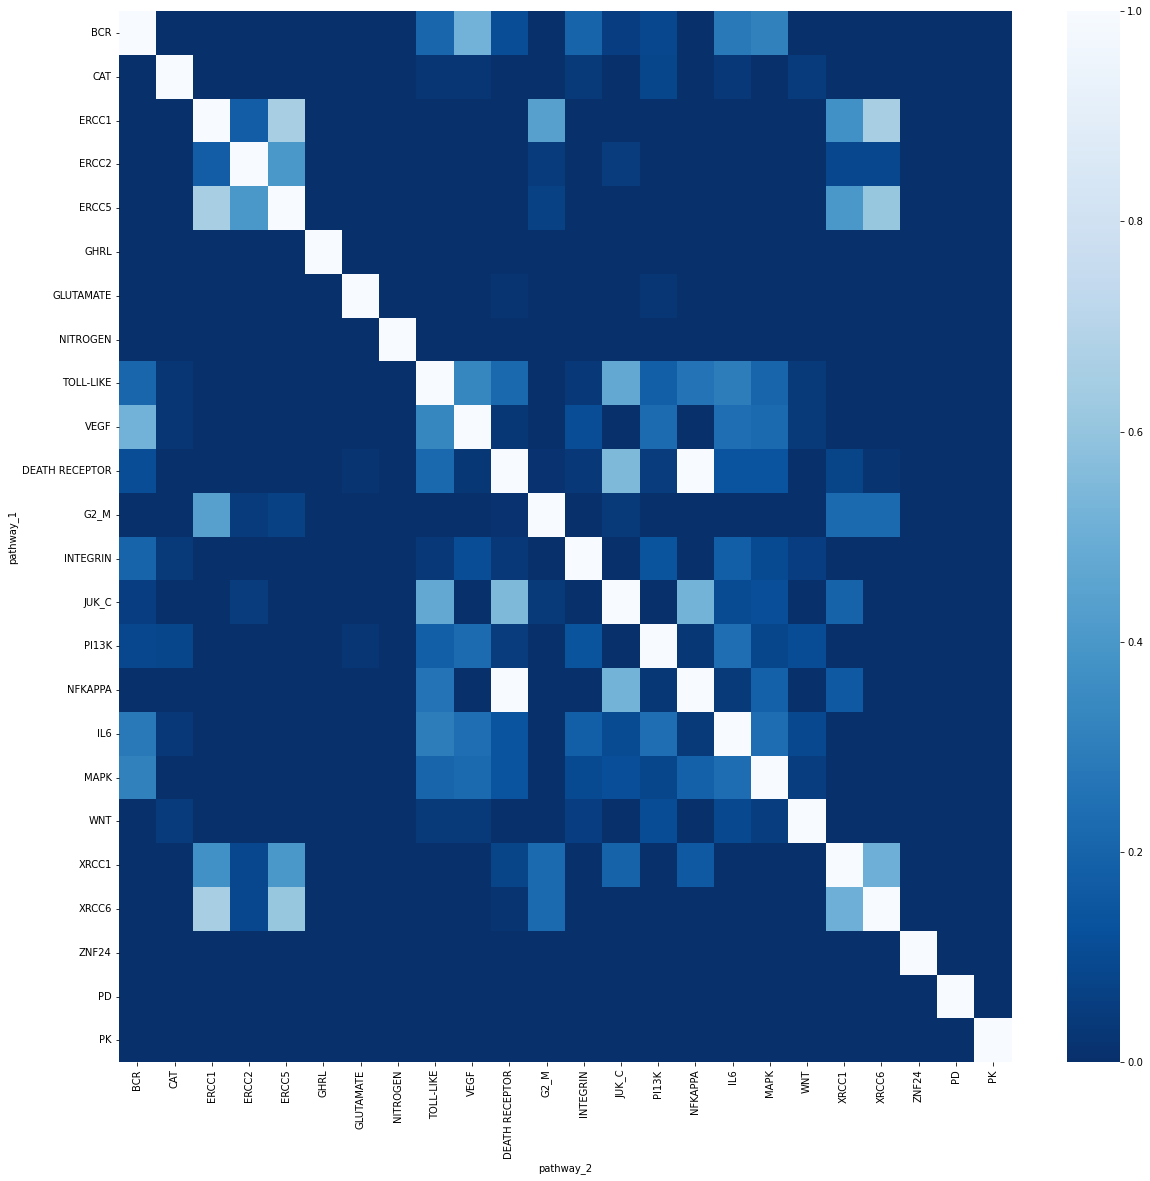

In [ ]:
plt.figure(figsize=(20,20))
fig = sns.heatmap(df_pivot, xticklabels=True, yticklabels=True, cmap="Blues_r")
fig.set(xlabel="pathway_2", ylabel="pathway_1")
plt.margins(5)
plt.subplots_adjust(bottom=0.15)
plt.savefig("./graphs/heatmap")

In [ ]:
np.mean(forbes)

0.09243751819340122

Low level of similarity was observed amongst gene sets with the exception to NFkappaB pathway and Death Receptor Signaling Pathay 

Examine Similarities between Gene Set Pairs using Corrected Jaccard Index

In [ ]:
def c_jaccard_similarity(dict1,dict2):
    sim_list = []
    for (x,l1) in dict1.items():
        for (y,l2) in dict2.items():
            A_n_B = len(set(l1).intersection(set(l2)))
            A = len(set(l1))
            B = len(set(l2))
            

            j = A_n_B/(A+B-A_n_B+0.000001) 
            sim_list.append((x,y,j))
    return sim_list

In [ ]:
similarity_list = c_jaccard_similarity(combined_dict, combined_dict)

In [ ]:
df  = pd.DataFrame({"path1" : p1, "path2" : p2, "jaccard": forbes})

df_pivot = pd.pivot_table(df, index = ["path1"], columns = ["path2"], values = ["jaccard"])
# make pivot long dataframe   
p1 = []
p2 = []
jaccard = []
for i in similarity_list:
    path1, path2, score = i
    print(path1, path2, score)
    p1.append(path1)
    p2.append(path2)
    jaccard.append(score)

pk pk 0.9999999230769291
pk pd 0.0
pk ZNF24 0.0
pk ERCC5 0.0
pk GHRL 0.0
pk CAT 0.0
pk XRCC1 0.0
pk XRCC6 0.0
pk ERCC1 0.0
pk ERCC2 0.0
pk KEGG_NITROGEN_METABOLISM 0.0
pk KEGG_TOLL_LIKE_RECEPTOR_SIGNALING_PATHWAY 0.0
pk REACTOME_TNFR1_INDUCED_NFKAPPAB_SIGNALING_PATHWAY 0.0
pk BIOCARTA_BCR_PATHWAY 0.0
pk REACTOME_PI3K_AKT_SIGNALING_IN_CANCER 0.0
pk REACTOME_G2_M_DNA_DAMAGE_CHECKPOINT 0.0
pk WP_P38_MAPK_SIGNALING_PATHWAY 0.0
pk WP_WNTBETACATENIN_SIGNALING_PATHWAY_IN_LEUKEMIA 0.0
pk REACTOME_INTEGRIN_SIGNALING 0.0
pk KEGG_VEGF_SIGNALING_PATHWAY 0.0
pk WP_IL6_SIGNALING_PATHWAY 0.0
pk REACTOME_DEATH_RECEPTOR_SIGNALLING 0.0
pk REACTOME_JNK_C_JUN_KINASES_PHOSPHORYLATION_AND_ACTIVATION_MEDIATED_BY_ACTIVATED_HUMAN_TAK1 0.0
pk GOBP_GLUTAMATE_RECEPTOR_SIGNALING_PATHWAY 0.0
pd pk 0.0
pd pd 0.9999999375000038
pd ZNF24 0.0
pd ERCC5 0.0
pd GHRL 0.0
pd CAT 0.0
pd XRCC1 0.0
pd XRCC6 0.0
pd ERCC1 0.0
pd ERCC2 0.0
pd KEGG_NITROGEN_METABOLISM 0.0
pd KEGG_TOLL_LIKE_RECEPTOR_SIGNALING_PATHWAY 0.0
pd REACTOM

WP_WNTBETACATENIN_SIGNALING_PATHWAY_IN_LEUKEMIA GOBP_GLUTAMATE_RECEPTOR_SIGNALING_PATHWAY 0.0
REACTOME_INTEGRIN_SIGNALING pk 0.0
REACTOME_INTEGRIN_SIGNALING pd 0.0
REACTOME_INTEGRIN_SIGNALING ZNF24 0.0
REACTOME_INTEGRIN_SIGNALING ERCC5 0.0
REACTOME_INTEGRIN_SIGNALING GHRL 0.0
REACTOME_INTEGRIN_SIGNALING CAT 0.012987012818350484
REACTOME_INTEGRIN_SIGNALING XRCC1 0.0
REACTOME_INTEGRIN_SIGNALING XRCC6 0.0
REACTOME_INTEGRIN_SIGNALING ERCC1 0.0
REACTOME_INTEGRIN_SIGNALING ERCC2 0.0
REACTOME_INTEGRIN_SIGNALING KEGG_NITROGEN_METABOLISM 0.0
REACTOME_INTEGRIN_SIGNALING KEGG_TOLL_LIKE_RECEPTOR_SIGNALING_PATHWAY 0.007812499938964845
REACTOME_INTEGRIN_SIGNALING REACTOME_TNFR1_INDUCED_NFKAPPAB_SIGNALING_PATHWAY 0.0
REACTOME_INTEGRIN_SIGNALING BIOCARTA_BCR_PATHWAY 0.07142857015306125
REACTOME_INTEGRIN_SIGNALING REACTOME_PI3K_AKT_SIGNALING_IN_CANCER 0.03124999975585938
REACTOME_INTEGRIN_SIGNALING REACTOME_G2_M_DNA_DAMAGE_CHECKPOINT 0.0
REACTOME_INTEGRIN_SIGNALING WP_P38_MAPK_SIGNALING_PATHWAY 0.03389

In [ ]:
df_pivot.columns = ["BCR","CAT","ERCC1","ERCC2","ERCC5","GHRL","GLUTAMATE","NITROGEN","TOLL-LIKE","VEGF","DEATH RECEPTOR",
                    "G2_M","INTEGRIN","JUK_C","PI13K","NFKAPPA","IL6","MAPK","WNT","XRCC1","XRCC6","ZNF24","PD","PK"]
df_pivot.index = ["BCR","CAT","ERCC1","ERCC2","ERCC5","GHRL","GLUTAMATE","NITROGEN","TOLL-LIKE","VEGF","DEATH RECEPTOR",
                    "G2_M","INTEGRIN","JUK_C","PI13K","NFKAPPA","IL6","MAPK","WNT","XRCC1","XRCC6","ZNF24","PD","PK"]


Text(0.5, 1.0, 'Pair-Wise Corrected Jaccard Similarity for Gene Sets')

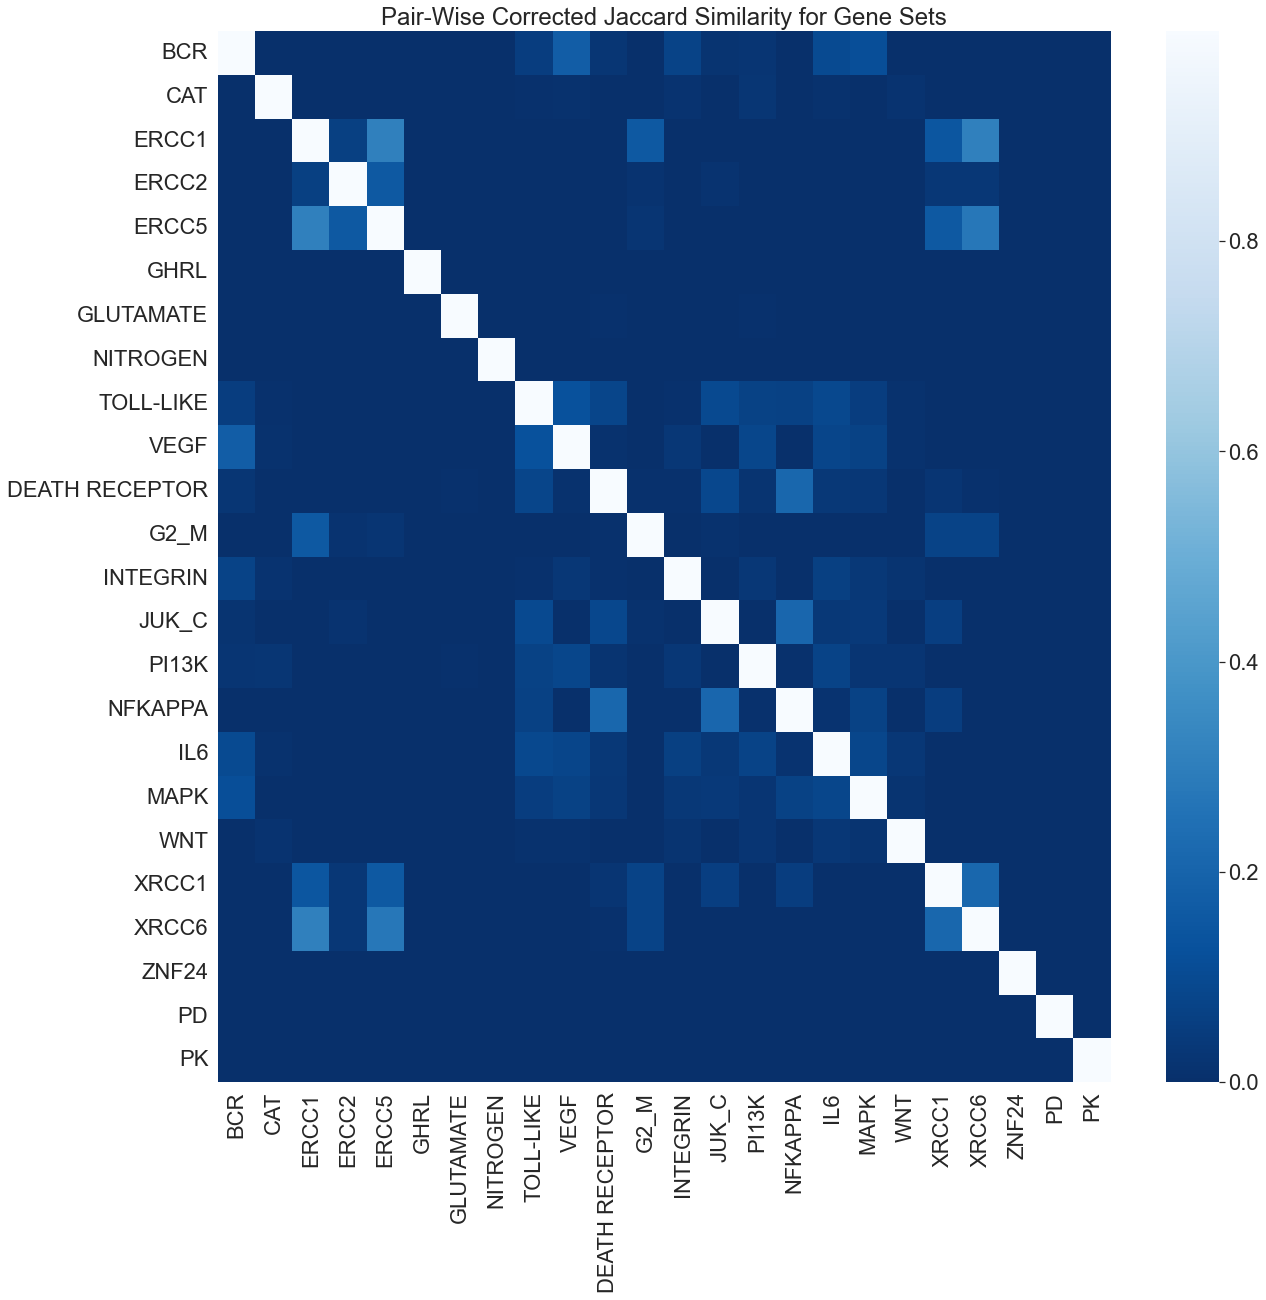

In [ ]:
plt.figure(figsize=(20,20))
fig = sns.heatmap(df_pivot, xticklabels=True, yticklabels=True, cmap="Blues_r")
fig.set(xlabel="", ylabel="")
plt.margins(5)
plt.subplots_adjust(bottom=0.15)
plt.savefig("./graphs/heatmap")
sns.set(font_scale=2)
plt.title("Pair-Wise Corrected Jaccard Similarity for Gene Sets")

### Sonis 14 Gene Sets

TNFR1-Induced NFkB signaling pathway is a subset of death receptor signaling pathway
and thus will be removed from sonis dict

In [ ]:
REACTOME_TNFR1_INDUCED_NFKAPPAB_SIGNALING_PATHWAY = sonis_dict.pop('REACTOME_TNFR1_INDUCED_NFKAPPAB_SIGNALING_PATHWAY')

In [ ]:
# Check if the pathway has been properly removed 
len(sonis_dict.keys())

Rename keys in sonis_dict for memory saving in JAG analysis 

In [ ]:
key_list = [("NIT",'KEGG_NITROGEN_METABOLISM'),("TL","KEGG_TOLL_LIKE_RECEPTOR_SIGNALING_PATHWAY"),("BCR",'BIOCARTA_BCR_PATHWAY'),("PI3K_AKT","REACTOME_PI3K_AKT_SIGNALING_IN_CANCER"),("G2",'REACTOME_G2_M_DNA_DAMAGE_CHECKPOINT'),("P38",'WP_P38_MAPK_SIGNALING_PATHWAY'),("WNT",'WP_WNTBETACATENIN_SIGNALING_PATHWAY_IN_LEUKEMIA'),
("INTEGRIN",'REACTOME_INTEGRIN_SIGNALING'),("VEGF",'KEGG_VEGF_SIGNALING_PATHWAY'),("IL16",'WP_IL6_SIGNALING_PATHWAY'),("DR",'REACTOME_DEATH_RECEPTOR_SIGNALLING'),("JNK",'REACTOME_JNK_C_JUN_KINASES_PHOSPHORYLATION_AND_ACTIVATION_MEDIATED_BY_ACTIVATED_HUMAN_TAK1'),("GLU",'GOBP_GLUTAMATE_RECEPTOR_SIGNALING_PATHWAY')]

In [ ]:
temp = dict(sonis_dict) #this makes a shallow copy of sonis_dict so any changes will be made to temp rather than sonis_dict alternatively can use .copy()

In [ ]:
def ch_key(k_list):
    sonis_dict_abbr = {}
    for tup in k_list:
        sonis_dict_abbr[tup[0]] = temp.pop(tup[1])
    return sonis_dict_abbr

In [ ]:
sonis_dict_abbr = ch_key(key_list)

In [ ]:
len(sonis_dict_abbr)

13

### Finalized 18 Gene Sets for Downstream JAG Analysis 

In [ ]:
master_pathway_dict.update(sonis_dict)
master_pathway_dict

{'FOLATE': ['MTHFD1',
  'FTCD',
  'ADA',
  'FGPS',
  'MTRR',
  'NT5E',
  'MTR',
  'SHMT1',
  'MTHFS',
  'GGH',
  'PPAT',
  'DHFR',
  'MTHFR',
  'SLC46A1',
  'SHMT2',
  'ALDH1L1',
  'CBS',
  'GART',
  'TYMS',
  'ATIC'],
 'MTX_PK': ['ABCB1',
  'ABCC1',
  'ABCC2',
  'ABCC3',
  'ABCG2',
  'FOLR1',
  'SLC19A1',
  'SLC22A6',
  'SLC22A8',
  'SLC46A1',
  'SLCO1A2',
  'SLCO1B1',
  'SLCO1B3'],
 'PEROXISOME': ['PEX19',
  'ACOT8',
  'PHYH',
  'ACSL3',
  'ECH1',
  'ACSL1',
  'PEX1',
  'PEX10',
  'ACSL6',
  'PEX3',
  'ACSL5',
  'ACSL4',
  'PEX12',
  'PEX2',
  'PEX13',
  'PEX14',
  'PEX16',
  'DAO',
  'ACOX3',
  'PEX5',
  'ACOX2',
  'PXMP2',
  'PEX7',
  'ACOX1',
  'PEX6',
  'PXMP4',
  'FAR1',
  'FAR2',
  'PEX11G',
  'PAOX',
  'CRAT',
  'SLC27A2',
  'PEX11A',
  'PEX11B',
  'HSD17B4',
  'EHHADH',
  'CROT',
  'PEX26',
  'PMVK',
  'PIPOX',
  'HAO2',
  'HAO1',
  'IDH1',
  'GSTK1',
  'IDH2',
  'EPHX2',
  'DHRS4',
  'SOD1',
  'BAAT',
  'SOD2',
  'SLC25A17',
  'CAT',
  'AMACR',
  'AGPS',
  'GNPAT',
  'AGXT',

## Prepare genes for JAG gene.set input list 

In [ ]:
with open("./gene_set_results/pathway_file.txt","w") as f:
    for k,v in master_pathway_dict.items():
        print(k,"\n",v,"\n", file=f)


In [ ]:
import mygene

def get_id(gene_list):
    mg = mygene.MyGeneInfo()
    out = mg.querymany(gene_list, scopes='symbol', fields='entrezgene', species='human')
    entrezid_list = []
    problem_list = []
#     print(out)
    for gene in out:
        try:
            entrezid_list.append(gene["entrezgene"])
        except:
            problem_list.append(gene["query"])
            
    print("notfound", set(problem_list))
    print (entrezid_list)
    return entrezid_list  

In [ ]:
t_list = []
for g_list in master_pathway_dict.values():
    t_list.append(get_id(g_list))

querying 1-20...done.
Finished.
1 input query terms found no hit:
	['FGPS']
Pass "returnall=True" to return complete lists of duplicate or missing query terms.
notfound {'FGPS'}
['4522', '10841', '100', '4552', '4907', '4548', '6470', '10588', '8836', '5471', '1719', '4524', '113235', '6472', '10840', '875', '2618', '7298', '471']
querying 1-13...done.
Finished.
notfound set()
['5243', '4363', '1244', '8714', '9429', '2348', '6573', '9356', '9376', '113235', '6579', '10599', '28234']
querying 1-77...done.
Finished.
notfound set()
['5824', '10005', '5264', '2181', '1891', '2180', '5189', '5192', '23305', '8504', '51703', '2182', '5193', '5828', '5194', '5195', '9409', '1610', '8310', '5830', '8309', '5827', '5191', '51', '5190', '11264', '84188', '55711', '92960', '196743', '1384', '11001', '8800', '8799', '3295', '1962', '54677', '55670', '10654', '51268', '51179', '54363', '3417', '373156', '3418', '2053', '10901', '6647', '570', '6648', '10478', '847', '23600', '8540', '8443', '189',

Finished.
notfound set()
['183', '207', '572', '598', '1387', '1401', '2549', '2885', '2932', '3055', '3065', '3569', '3570', '3572', '3659', '3716', '3717', '3726', '5604', '5605', '6416', '6885', '5594', '5595', '8648', '51701', '2063', '5295', '5296', '639', '5580', '5781', '5879', '6198', '6464', '9021', '6654', '6772', '6774', '7076', '7297', '7409', '7432']
querying 1-141...done.
Finished.
notfound set()
['26574', '29', '6868', '11214', '51107', '83464', '396', '9138', '9639', '55160', '9826', '23365', '22899', '27237', '9828', '23370', '128272', '9181', '26084', '50650', '100271715', '445328', '389337', '54848', '84904', '50649', '55701', '7984', '9459', '8874', '23229', '572', '9530', '10018', '27018', '329', '330', '843', '835', '836', '841', '8837', '1147', '25999', '1540', '1894', '8772', '355', '356', '2245', '221472', '89846', '121512', '10672', '3065', '3066', '8841', '3551', '8517', '3654', '23421', '6453', '8997', '84894', '8567', '4099', '9500', '6885', '5599', '4168',

In [ ]:
%store t_list

Stored 't_list' (list)


In [ ]:
len(t_list[9])

92

In [ ]:
#FGPS does not exist
not_found = ['H2BS1', 'H2BU1', 'H4-16']
id = ["54145","128312","8359"]

In [ ]:
t_list[9].extend(id)

In [ ]:
t_list

[['4522',
  '10841',
  '100',
  '4552',
  '4907',
  '4548',
  '6470',
  '10588',
  '8836',
  '5471',
  '1719',
  '4524',
  '113235',
  '6472',
  '10840',
  '875',
  '2618',
  '7298',
  '471'],
 ['5243',
  '4363',
  '1244',
  '8714',
  '9429',
  '2348',
  '6573',
  '9356',
  '9376',
  '113235',
  '6579',
  '10599',
  '28234'],
 ['5824',
  '10005',
  '5264',
  '2181',
  '1891',
  '2180',
  '5189',
  '5192',
  '23305',
  '8504',
  '51703',
  '2182',
  '5193',
  '5828',
  '5194',
  '5195',
  '9409',
  '1610',
  '8310',
  '5830',
  '8309',
  '5827',
  '5191',
  '51',
  '5190',
  '11264',
  '84188',
  '55711',
  '92960',
  '196743',
  '1384',
  '11001',
  '8800',
  '8799',
  '3295',
  '1962',
  '54677',
  '55670',
  '10654',
  '51268',
  '51179',
  '54363',
  '3417',
  '373156',
  '3418',
  '2053',
  '10901',
  '6647',
  '570',
  '6648',
  '10478',
  '847',
  '23600',
  '8540',
  '8443',
  '189',
  '4598',
  '5825',
  '5826',
  '55825',
  '255027',
  '10455',
  '8528',
  '83594',
  '3155',
 

In [ ]:
final_list = []
for i in range(0,len(t_list)):
    for g in t_list[i]:
        final_list.append((g,list(master_pathway_dict.keys())[i])) 
final_list

[('4522', 'FOLATE'),
 ('10841', 'FOLATE'),
 ('100', 'FOLATE'),
 ('4552', 'FOLATE'),
 ('4907', 'FOLATE'),
 ('4548', 'FOLATE'),
 ('6470', 'FOLATE'),
 ('10588', 'FOLATE'),
 ('8836', 'FOLATE'),
 ('5471', 'FOLATE'),
 ('1719', 'FOLATE'),
 ('4524', 'FOLATE'),
 ('113235', 'FOLATE'),
 ('6472', 'FOLATE'),
 ('10840', 'FOLATE'),
 ('875', 'FOLATE'),
 ('2618', 'FOLATE'),
 ('7298', 'FOLATE'),
 ('471', 'FOLATE'),
 ('5243', 'MTX_PK'),
 ('4363', 'MTX_PK'),
 ('1244', 'MTX_PK'),
 ('8714', 'MTX_PK'),
 ('9429', 'MTX_PK'),
 ('2348', 'MTX_PK'),
 ('6573', 'MTX_PK'),
 ('9356', 'MTX_PK'),
 ('9376', 'MTX_PK'),
 ('113235', 'MTX_PK'),
 ('6579', 'MTX_PK'),
 ('10599', 'MTX_PK'),
 ('28234', 'MTX_PK'),
 ('5824', 'PEROXISOME'),
 ('10005', 'PEROXISOME'),
 ('5264', 'PEROXISOME'),
 ('2181', 'PEROXISOME'),
 ('1891', 'PEROXISOME'),
 ('2180', 'PEROXISOME'),
 ('5189', 'PEROXISOME'),
 ('5192', 'PEROXISOME'),
 ('23305', 'PEROXISOME'),
 ('8504', 'PEROXISOME'),
 ('51703', 'PEROXISOME'),
 ('2182', 'PEROXISOME'),
 ('5193', 'PEROXISO

In [ ]:
with open ("./gene_set_results/gene_set_file.txt", "w") as f:
    for l in final_list:
        l = "\t".join(l)
        print(l,file=f)